# Indicador de estrés financiero

Este notebook construye un indicador de estrés financiero a partir de variables macroeconómicas y financieras. El flujo incluye carga y exploración de datos, análisis de relaciones entre variables, estimación de una regresión logística para aproximar la probabilidad de crisis y visualización de la serie estimada junto con su tendencia.

El archivo fue preparado para poder ejecutarse tanto en un entorno local como en Google Colab.

In [ ]:
import pandas as pd
import statsmodels as stats
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression

try:
    from google.colab import files
    EN_COLAB = True
except ImportError:
    files = None
    EN_COLAB = False

## 1. Carga de datos

En esta sección se define el archivo de entrada y se carga la base de trabajo. Si el notebook se ejecuta en local, toma `Datos Modelo.xlsx` desde la carpeta del proyecto; en Colab, permite usar carga manual como respaldo.

In [ ]:
DATA_FILE = Path("Datos Modelo.xlsx")

if DATA_FILE.exists():
    data_source = DATA_FILE
elif EN_COLAB:
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    data_source = Path(uploaded_name)
else:
    raise FileNotFoundError("No se encontro 'Datos Modelo.xlsx' en la carpeta de trabajo.")

print(f"Usando archivo: {data_source}")

Saving Datos Modelo 2.xlsx to Datos Modelo 2.xlsx


In [ ]:
Data = pd.read_excel(data_source)
Data = pd.DataFrame(Data)
Data.head()
Data.describe()

,MTI,Crisis,i,M3,Incremento M3,EMAE,Incremento EMAE,DF,TCR,TCR-M,TCR-M-1,DCC,DCC-1,IPMP,Imp,Reservas,Incremento Reservas,Res/Imp,Deuda ext
count,235.000000,235.000000,235.000000,2.330000e+02,232.000000,233.000000,222.000000,235.000000,235.000000,2.350000e+02,235.000000,195.000000,190.000000,234.000000,234.000000,235.000000,234.000000,234.000000,210.000000
mean,0.522162,0.114894,22.971809,3.666965e+09,0.024919,136.602120,0.019740,-0.027120,121.511690,-9.675476e-15,3.027466,-0.008652,-0.008545,235.793852,4648.324786,38914.604255,0.007866,8.787325,194921.373448
std,2.000497,0.319574,17.738705,6.254803e+09,0.024237,14.581813,0.095709,0.032252,26.904886,2.690489e+01,26.876117,0.022042,0.022322,58.753666,1482.176571,13113.580585,0.060432,3.551216,54503.589702
min,-4.879000,0.000000,1.125000,1.197259e+08,-0.067240,95.125392,-1.000000,-0.084315,74.049951,-4.746174e+01,-47.168529,-0.057658,-0.057658,132.260973,1364.000000,9326.000000,-0.298750,4.898084,130145.321159
25%,-0.563553,0.000000,10.843750,3.013856e+08,0.010178,128.435940,-0.017713,-0.049649,98.011820,-2.349987e+01,-19.876766,-0.025244,-0.026452,198.704056,3536.750000,29042.500000,-0.017959,6.684564,153754.171744
50%,0.244744,0.000000,19.187500,9.234179e+08,0.020005,143.473925,0.026717,-0.032500,117.541794,-3.969896e+00,-0.880166,-0.008685,-0.008440,217.021463,4767.000000,42531.000000,0.004114,7.600471,161281.066593
75%,1.158014,0.000000,29.843750,3.844518e+09,0.033412,147.242539,0.073198,0.003500,148.358828,2.684714e+01,30.704982,0.009536,0.009903,290.798203,5736.000000,47519.500000,0.033326,9.247003,267537.066109
max,11.206726,1.000000,92.875000,3.392502e+10,0.116347,152.552876,0.315511,0.039700,169.352896,4.784121e+01,47.841206,0.027376,0.027376,372.457338,8664.000000,71663.000000,0.285449,24.762612,283129.143831


## 2. Exploracion inicial

Primero se revisan estadísticos descriptivos y luego se observan correlaciones y relaciones bivariadas entre variables relevantes para el indicador.

In [ ]:
# Paso opcional: eliminar columnas si se quiere trabajar con una seleccion reducida.
# Data = Data.drop(['MTI', 'M3', 'EMAE', 'TCR', 'TCR-M', 'Imp', 'DCC', 'Reservas'], axis=1)

In [ ]:
# Paso opcional: eliminar filas con valores faltantes antes de algunos gráficos o modelos.
# Data = Data.dropna()
Data.head()

,Fecha,MTI,Crisis,i,M3,Incremento M3,EMAE,Incremento EMAE,DF,TCR,TCR-M,TCR-M-1,DCC,DCC-1,IPMP,Imp,Reservas,Incremento Reservas,Res/Imp,Deuda ext
0,2004-01-01,0.000000,0,1.5000,119725909.0,NaN,98.237092,NaN,0.0397,159.536848,38.025158,32.536347,NaN,NaN,161.449069,1609.0,9326,NaN,5.796147,NaN
1,2004-02-01,-1.762462,0,1.1250,120882595.0,0.009661,98.087555,NaN,0.0397,159.662715,38.151025,31.698913,NaN,NaN,167.807290,1364.0,10289,0.103260,7.543255,NaN
2,2004-03-01,2.804771,1,1.6875,120780924.0,-0.000841,97.663962,NaN,0.0397,155.118220,33.606530,24.485429,NaN,NaN,183.684327,1690.0,10517,0.022160,6.223077,NaN
3,2004-04-01,-0.400921,0,1.8125,123897338.0,0.025802,95.125392,NaN,0.0397,151.164852,29.653162,25.093437,NaN,NaN,184.549316,1651.0,10971,0.043168,6.645064,NaN
4,2004-05-01,7.123325,1,3.8750,128684876.0,0.038641,96.985385,NaN,0.0397,155.046584,33.534893,28.269468,NaN,NaN,181.897997,1792.0,11374,0.036733,6.347098,NaN


<ipython-input-22-8166f14d7420>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  DataCorr = Data.corr(method='pearson')


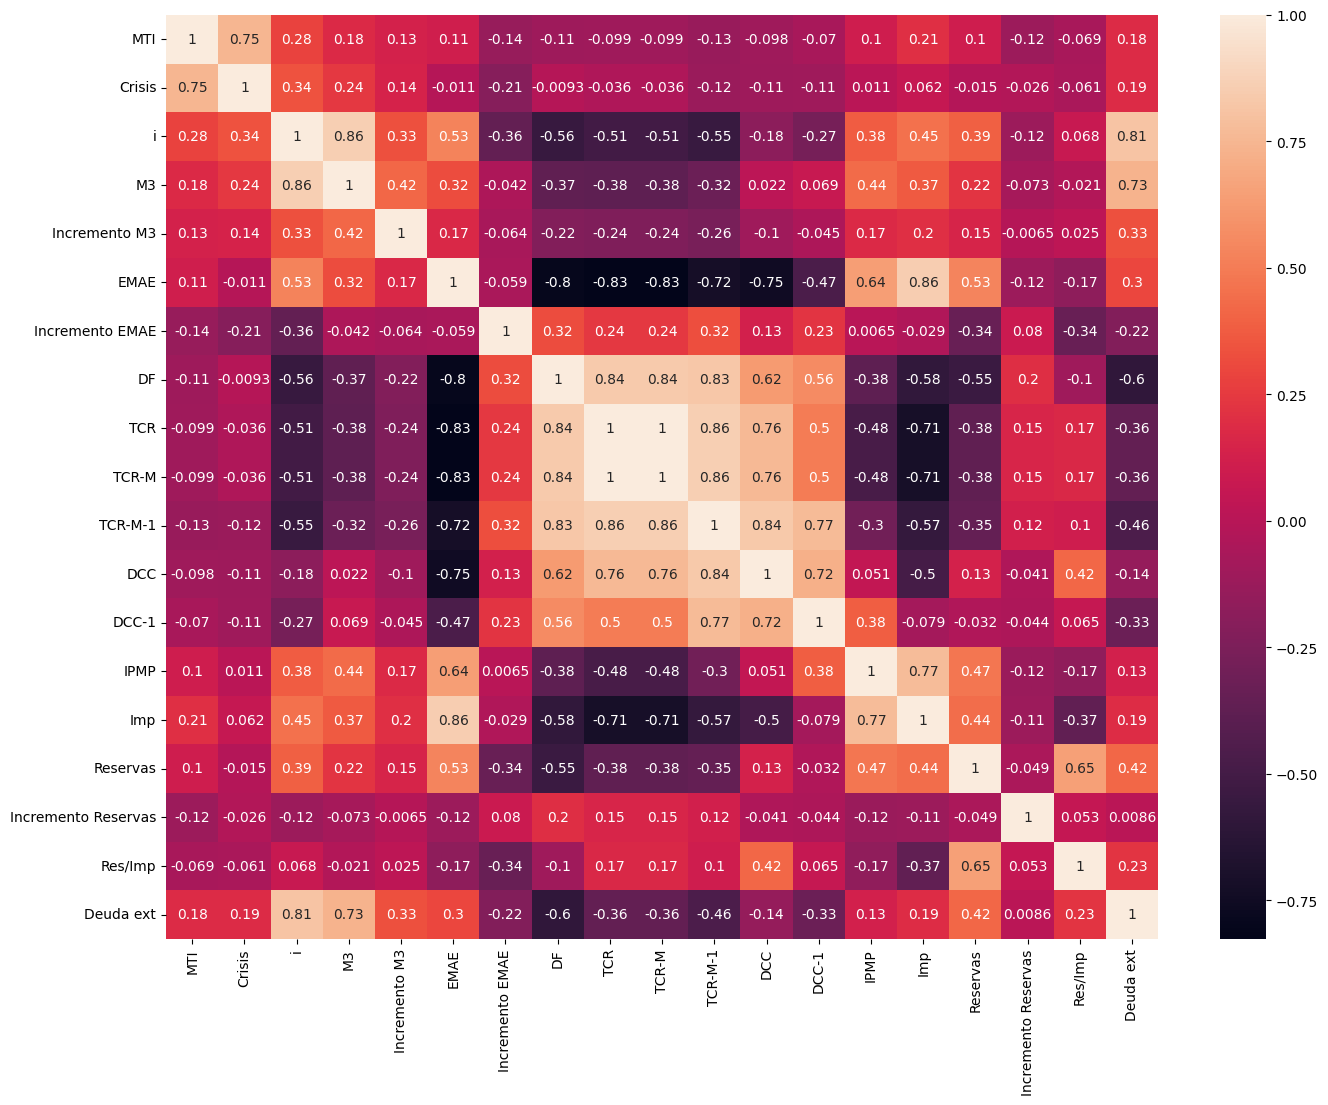

In [ ]:
DataCorr = Data.corr(method='pearson')

plt.figure(figsize=(16, 12))
sns.heatmap(DataCorr, annot=True)
plt.show()

## Vemos que el hecho de tener 'Crisis' se relaciona linealmente sobre todo con subas de la tasa (i)
## y con el agregado M3 (igualmente para la regresión usamos su incremento)
## Por otra parte, el incremento del EMAE (Actividad Económica) se relaciona negativamente

<Axes: xlabel='MTI', ylabel='DF'>

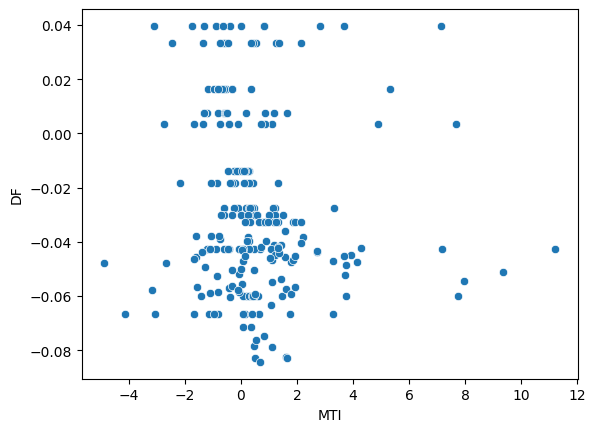

In [ ]:
sns.scatterplot(x = "MTI",
                y = "DF", data = Data)

<Axes: xlabel='Crisis', ylabel='Incremento M3'>

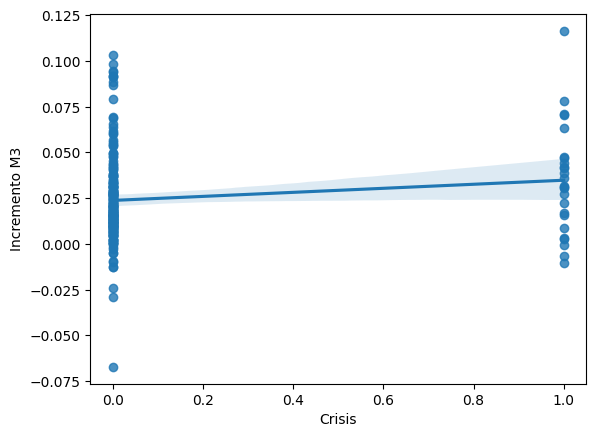

In [ ]:
sns.regplot(x = "Crisis", y = "Incremento M3", data = Data)

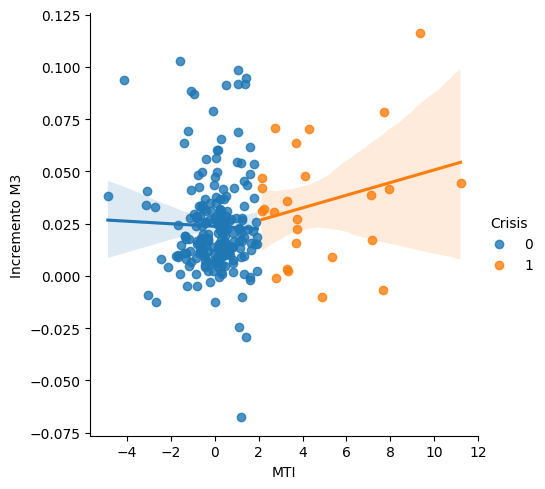

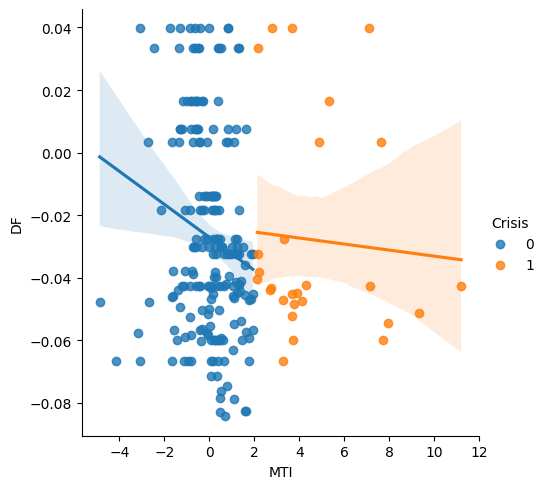

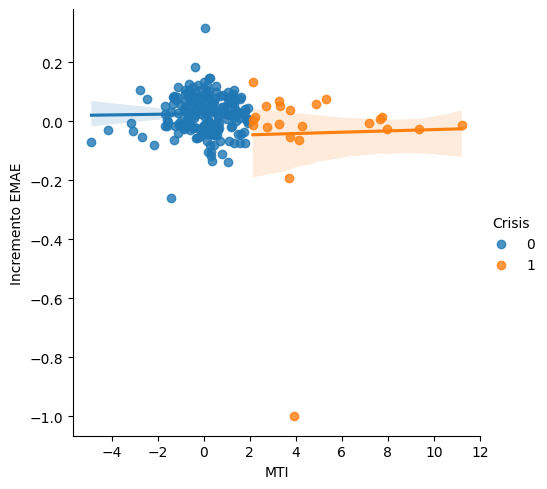

In [ ]:
sns.lmplot(x = "MTI", y = "Incremento M3",
           hue = "Crisis", data = Data)
sns.lmplot(x = "MTI", y = "DF",
           hue = "Crisis", data = Data)
sns.lmplot(x = "MTI", y = "Incremento EMAE",
           hue = "Crisis", data = Data)

## 3. Modelo de probabilidad de crisis

Se estima una regresión logística para aproximar la probabilidad de un episodio de estrés o crisis en función de variables monetarias, cambiarias y de actividad.

In [ ]:
# Regresión logística para la probabilidad de incurrir en un evento de estrés
DataLogit = Data.drop(['EMAE', 'TCR', 'TCR-M', 'Imp', 'DCC','Reservas'], axis=1)
DataLogit = DataLogit.dropna()
Y = DataLogit['Crisis']
X = DataLogit[['Incremento M3', 'i', 'Incremento EMAE', 'DF', 'TCR-M-1', 'DCC-1', 'IPMP', 'Incremento Reservas', 'Res/Imp', 'Deuda ext']]
ModeloLogit = sm.Logit(Y, X)
ResultadosLogit = ModeloLogit.fit()
print(ResultadosLogit.summary())

Optimization terminated successfully.
         Current function value: 0.261544
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Crisis   No. Observations:                  188
Model:                          Logit   Df Residuals:                      178
Method:                           MLE   Df Model:                            9
Date:                Thu, 24 Aug 2023   Pseudo R-squ.:                  0.2282
Time:                        14:31:19   Log-Likelihood:                -49.170
converged:                       True   LL-Null:                       -63.710
Covariance Type:            nonrobust   LLR p-value:                 0.0006281
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Incremento M3          11.2790      9.687      1.164      0.244      -7.707      30.265
i 

In [ ]:
DataLogit.tail()

,Fecha,MTI,Crisis,i,M3,Incremento M3,Incremento EMAE,DF,TCR-M-1,DCC-1,IPMP,Incremento Reservas,Res/Imp,Deuda ext
228,2023-01-01,2.228435,1,69.3750,2.717245e+10,0.031809,0.014607,-0.038146,-19.189833,-0.009155,327.580793,-0.052267,7.002422,275093.366763
229,2023-02-01,2.131944,1,69.3750,2.831279e+10,0.041967,0.005480,-0.040511,-19.472877,-0.009155,325.851858,-0.015191,7.360907,275093.366763
230,2023-03-01,1.329922,0,72.4375,2.959863e+10,0.045416,0.014745,-0.042315,-19.830194,-0.009155,313.720209,0.165298,6.301052,275093.366763
231,2023-04-01,4.281775,1,87.5000,3.168247e+10,0.070403,-0.014503,-0.042289,-24.603986,-0.006927,310.878475,-0.026196,6.896569,275093.366763
232,2023-05-01,2.728877,1,91.9375,3.392502e+10,0.070782,-0.017661,-0.043211,-23.537772,-0.006927,292.162275,-0.010617,5.626997,275093.366763


In [ ]:
# Vemos los coeficientes con efecto marginal
LogitMargEff = ResultadosLogit.get_margeff(at = "mean")

print(LogitMargEff.summary())

        Logit Marginal Effects       
Dep. Variable:                 Crisis
Method:                          dydx
At:                              mean
                         dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Incremento M3           0.7027      0.612      1.149      0.251      -0.496       1.902
i                       0.0052      0.002      2.462      0.014       0.001       0.009
Incremento EMAE        -0.5539      0.495     -1.118      0.264      -1.525       0.417
DF                      0.7011      1.542      0.455      0.649      -2.321       3.723
TCR-M-1                 0.0010      0.002      0.586      0.558      -0.002       0.005
DCC-1                  -0.9932      1.313     -0.756      0.449      -3.567       1.580
IPMP                   -0.0003      0.000     -1.006      0.315      -0.001       0.000
Incremento Reservas    -0.0153      0.268     -0.057    

## 4. Serie estimada y tendencia

A partir del modelo se calcula la probabilidad predicha y se visualiza su evolución temporal. Luego se aplica un suavizado exponencial simple para resumir la tendencia del indicador.

45     0.050760
46     0.051266
47     0.050211
48     0.026618
49     0.023100
         ...   
228    0.465023
229    0.495290
230    0.575571
231    0.878950
232    0.932552
Length: 188, dtype: float64


<Axes: xlabel='Fecha'>

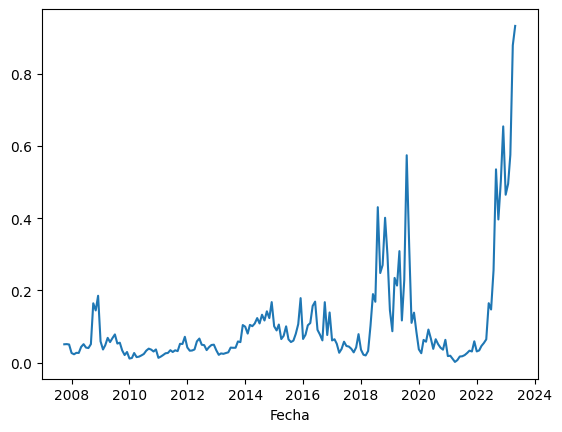

In [ ]:
# Cálculo de la probabilidad predicha y preparación de la serie para graficar
from matplotlib.ticker import PercentFormatter

Prediccion = ResultadosLogit.predict(X)
DataLogit = DataLogit.copy()
DataLogit['Fecha'] = pd.to_datetime(DataLogit['Fecha'])
DataLogit['Prediccion'] = Prediccion
DataLogit = DataLogit.sort_values('Fecha')

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=DataLogit,
    x='Fecha',
    y='Prediccion',
    ax=ax,
    color='#1f5aa6',
    linewidth=2.6,
    label='Probabilidad estimada'
)
ax.fill_between(DataLogit['Fecha'], DataLogit['Prediccion'], color='#8fb7e8', alpha=0.22)

crisis = DataLogit[DataLogit['Crisis'] == 1]
ax.scatter(
    crisis['Fecha'],
    crisis['Prediccion'],
    color='#c0392b',
    edgecolor='white',
    linewidth=0.8,
    s=55,
    zorder=5,
    label='Meses de crisis'
)

ax.set_title('Probabilidad estimada de estrés financiero', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, axis='y', linestyle='--', alpha=0.30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

45     0.050760
46     0.050760
47     0.050811
48     0.050751
49     0.048338
         ...   
228    0.238246
229    0.260924
230    0.284361
231    0.313482
232    0.370029
Name: Tendencia, Length: 188, dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<Axes: xlabel='Fecha', ylabel='Prediccion'>

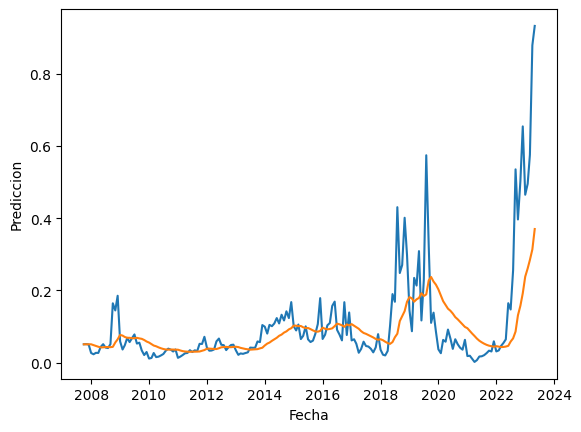

In [ ]:
from statsmodels.tsa.api import SimpleExpSmoothing

Tendencia = SimpleExpSmoothing(DataLogit['Prediccion']).fit(smoothing_level=0.1, optimized=False)
DataLogit['Tendencia'] = Tendencia.fittedvalues

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=DataLogit,
    x='Fecha',
    y='Prediccion',
    ax=ax,
    color='#9bb8d3',
    linewidth=1.8,
    alpha=0.9,
    label='Probabilidad estimada'
)
sns.lineplot(
    data=DataLogit,
    x='Fecha',
    y='Tendencia',
    ax=ax,
    color='#0b3c5d',
    linewidth=3,
    label='Tendencia suavizada'
)

ax.set_title('Evolución del indicador y tendencia suavizada', fontsize=16, fontweight='bold', pad=16)
ax.text(
    0.01,
    1.02,
    'Suavizado exponencial simple con smoothing_level = 0.1',
    transform=ax.transAxes,
    fontsize=10,
    color='#4f5b66'
)
ax.set_xlabel('')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, axis='y', linestyle='--', alpha=0.30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left', ncol=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## Para guardar o descargar
output_file = Path('DatosLogit.xlsx')
DataLogit.to_excel(output_file, index=False)
print(f"Archivo guardado en: {output_file.resolve()}")

if EN_COLAB:
    files.download(str(output_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Extensión posible

Como trabajo futuro, este análisis puede ampliarse con modelos alternativos de clasificación, por ejemplo Naive Bayes u otros algoritmos supervisados, para comparar desempeño y robustez frente a la regresión logística.